# COMM061 Group Coursework

## 1. Analysis and visualization of the dataset

### 1.1. Visualizing different distributions and analyzing the class imbalance between Sentiment (Positive/Negative) and Sarcasm (Sarcastic/Not Sarcastic) across all three varieties

In [1]:
import os

BASE_DIR = f"/scratch/{os.environ['USER']}"
os.environ["HF_HOME"] = f"{BASE_DIR}/hf_cache"

OUTPUT_DIR = f"{BASE_DIR}/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
import random
import torch
import numpy as np
SEED = 1234

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def device_string(force_cpu: bool = False):
    if force_cpu:
        return "cpu"
    return "cuda" if torch.cuda.is_available() else "cpu"

set_seed(1234)

FORCE_CPU = False
DEVICE = device_string(force_cpu=FORCE_CPU)
print("Device:", DEVICE)

Device: cuda


In [3]:
#Downloading spaCy model for English
import spacy
nlp = spacy.load("en_core_web_sm")

In [4]:
#Loading the dataset
from datasets import load_dataset, Dataset
dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

In [5]:
#Labels type to int
for df in (train_df, validation_df, test_df):
    df["Sentiment"] = df["Sentiment"].astype(int)
    df["Sarcasm"] = df["Sarcasm"].astype(int)

In [6]:
#Combining training and validation dataframes
import pandas as pd
eda_df = pd.concat([train_df, validation_df], ignore_index=True)

In [7]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [8]:
print(eda_df.head())

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0          0        0  
1          0        1  
2          1        0  
3          0        0  
4          1        0  


In [9]:
#Analysis and data visualization
summary_table = (
    eda_df.groupby(["variety", "source"])
    .size()
    .reset_index(name="count")
    .sort_values(["variety", "source"])
)

summary_table

,variety,source,count
0,en-AU,Google,428
1,en-AU,Reddit,812
2,en-IN,Google,778
3,en-IN,Reddit,738
4,en-UK,Google,835
5,en-UK,Reddit,469


Deduction: en-AU has majority of samples from Reddit, en-IN has almost equal samples from both sources and en-UK has majority of the samples from Google.

In [10]:
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4060 entries, 0 to 4059
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       4060 non-null   str  
 1   variety    4060 non-null   str  
 2   source     4060 non-null   str  
 3   Sentiment  4060 non-null   int64
 4   Sarcasm    4060 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.3 MB


Note: We have converted "Sentiment" and "Sarcasm" columns to type int in the previous cells

/scratch/vv00363/tmp/ipykernel_378018/3859073320.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Negative (0)", "Positive (1)"])
/scratch/vv00363/tmp/ipykernel_378018/3859073320.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not Sarcastic (0)", "Sarcastic (1)"])


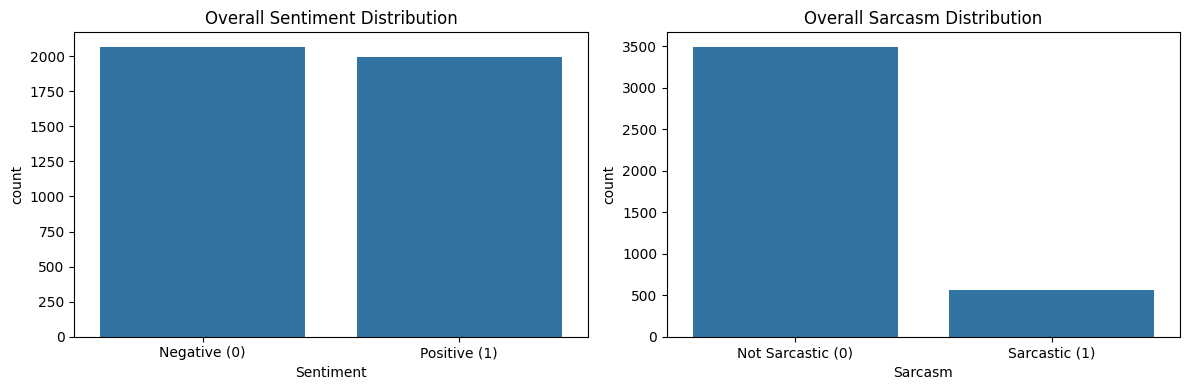

In [11]:
#class distribution for Sentiment and Sarcasm
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=eda_df, x="Sentiment", ax=axes[0])
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"])

sns.countplot(data=eda_df, x="Sarcasm", ax=axes[1])
axes[1].set_title("Overall Sarcasm Distribution")
axes[1].set_xticklabels(["Not Sarcastic (0)", "Sarcastic (1)"])

plt.tight_layout()
plt.show()

Sarcasm is highly imbalanced, hence we will rely on precision, recall and F1-score metrics instead of accuracy.

Text(0.5, 1.0, 'Source distribution')

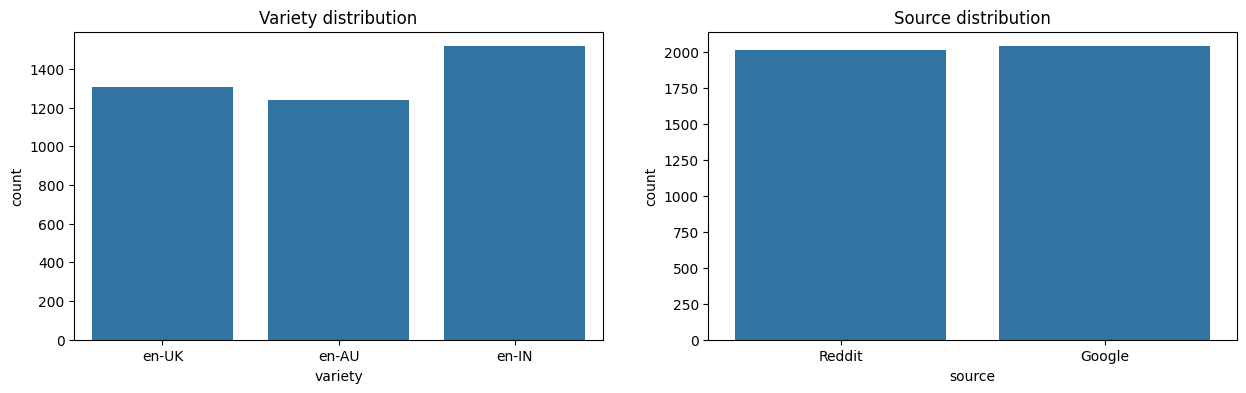

In [12]:
#class distribution by variety
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
#Variety distribution between English types
sns.countplot(data=eda_df, x="variety", ax=axes[0])
axes[0].set_title("Variety distribution")

#Source distribution of the reviews between Reddit and Google reviews
sns.countplot(data=eda_df, x="source", ax=axes[1])
axes[1].set_title("Source distribution")

There seems to be slightly more samples of the en-IN (Indian English variety) compared to the other 2 varieties. There are approximately equal samples from the 2 sources (Google and Reddit)  

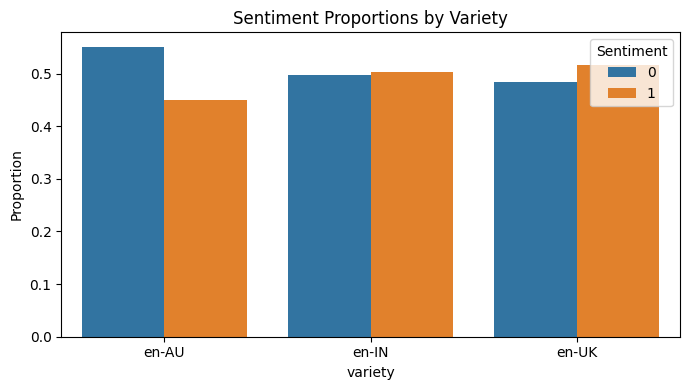

In [13]:
#Sentiment by variety - Normalized to get proportions
sentiment_variety_prop = (
    eda_df.groupby(["variety", "Sentiment"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name="proportion")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=sentiment_variety_prop, x="variety", y="proportion", hue="Sentiment")
plt.title("Sentiment Proportions by Variety")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

Proportion of Sentiment classes is almost equal in all Elglish varieties, just a bit higher proportion of negative sentiment in Australian English

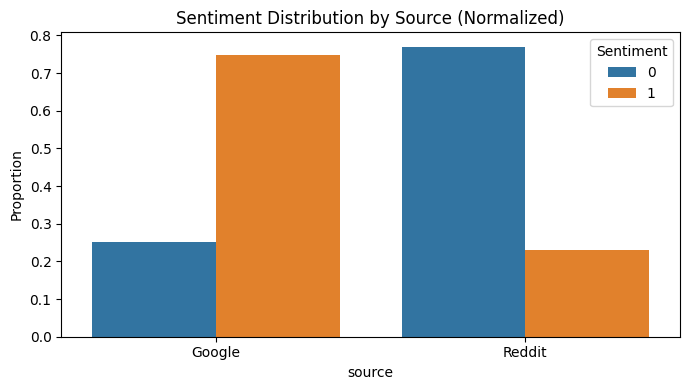

In [14]:
#Normalized Sentiment Distribution by Source
sentiment_dist2 = (
    eda_df
    .groupby(["source", "Sentiment"])
    .size()
    .reset_index(name="count")
)

#Normalize within each source
sentiment_dist2["proportion"] = (
    sentiment_dist2["count"] /
    sentiment_dist2.groupby("source")["count"].transform("sum")
)

plt.figure(figsize=(7,4))
sns.barplot(data=sentiment_dist2, x="source", y="proportion", hue="Sentiment")

plt.title("Sentiment Distribution by Source (Normalized)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

There seems to be a high proportion of Positive sentiment in the text from Google Reviews, and the opposite (high proportion of negative sentiment) in Reddit posts.

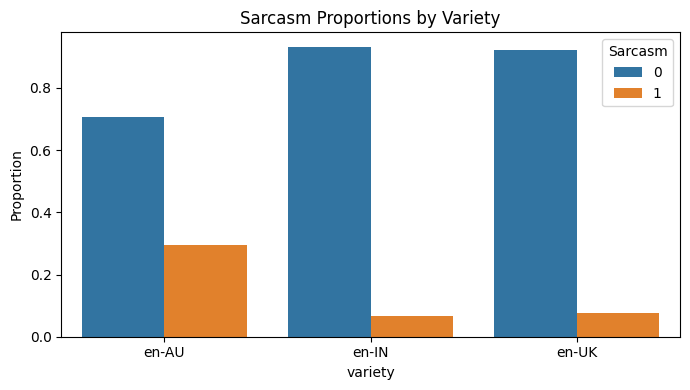

In [15]:
#SArcasm by variety - Normalized to get proportions
sarcasm_variety_prop = (
    eda_df.groupby(["variety", "Sarcasm"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name="proportion")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=sarcasm_variety_prop, x="variety", y="proportion", hue="Sarcasm")
plt.title("Sarcasm Proportions by Variety")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

The proportion of Sarcasm is quite low in all English varieties, the proportion is the highest in Australian English 

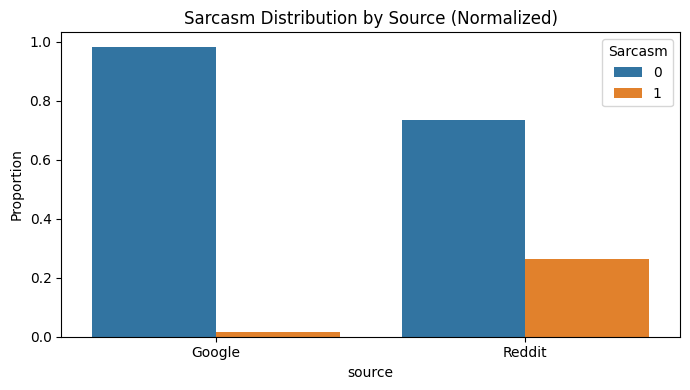

In [16]:
#Normalized Sarcasm Distribution by Source
sarcasm_dist2 = (
    eda_df
    .groupby(["source", "Sarcasm"])
    .size()
    .reset_index(name="count")
)

# Normalize within each source
sarcasm_dist2["proportion"] = (
    sarcasm_dist2["count"] /
    sarcasm_dist2.groupby("source")["count"].transform("sum")
)

plt.figure(figsize=(7,4))
sns.barplot(data=sarcasm_dist2, x="source", y="proportion", hue="Sarcasm")

plt.title("Sarcasm Distribution by Source (Normalized)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

The proportion of Sarcasm is very low in Google Review texts, but it is much higher in Reggit texts.

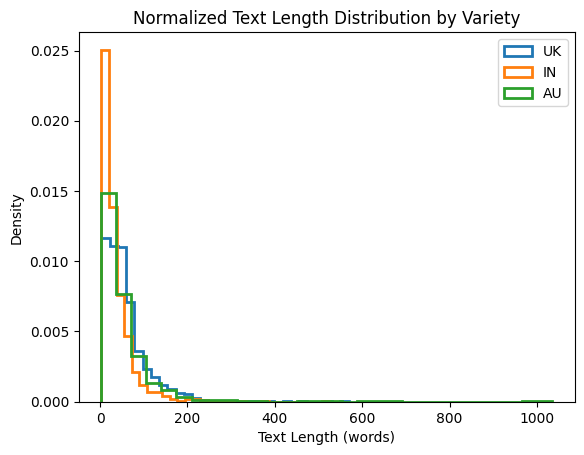

In [17]:
#Plotting Normalized sentence lengths distribution by English Variety in histogram format
eda_df["text_len_tokens"] = eda_df["text"].apply(lambda x: len(str(x).split()))
UK_lengths = eda_df[eda_df["variety"] == "en-UK"]["text"].apply(lambda x: len(str(x).split()))
IN_lengths = eda_df[eda_df["variety"] == "en-IN"]["text"].apply(lambda x: len(str(x).split()))
AU_lengths = eda_df[eda_df["variety"] == "en-AU"]["text"].apply(lambda x: len(str(x).split()))

plt.hist(UK_lengths, bins=30, histtype='step', linewidth=2, label="UK", density=True)
plt.hist(IN_lengths, bins=30, histtype='step', linewidth=2, label="IN", density=True)
plt.hist(AU_lengths, bins=30, histtype='step', linewidth=2, label="AU", density=True)

plt.legend()
plt.xlabel("Text Length (words)")
plt.ylabel("Density")
plt.title("Normalized Text Length Distribution by Variety")
plt.show()

Deduction: Shorter sentences(texts) are more frequent in Indian English in the training & validation datasets

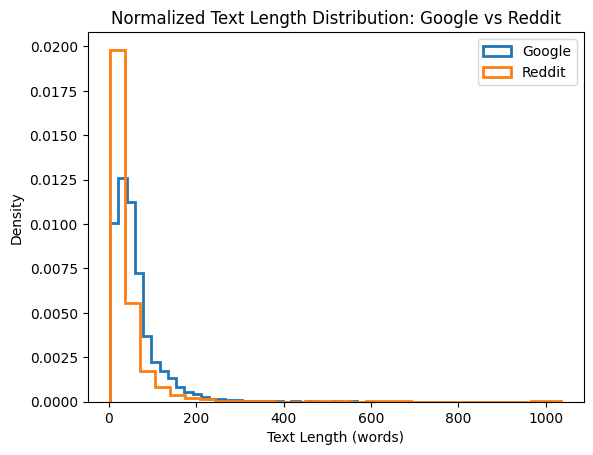

In [18]:
#Plotting Normalized sentence lengths distribution by Source in histogram format
google_lengths = eda_df[eda_df["source"] == "Google"]["text"].apply(lambda x: len(str(x).split()))
reddit_lengths = eda_df[eda_df["source"] == "Reddit"]["text"].apply(lambda x: len(str(x).split()))

plt.hist(google_lengths, bins=30, histtype='step', linewidth=2, label="Google", density=True)
plt.hist(reddit_lengths, bins=30, histtype='step', linewidth=2, label="Reddit", density=True)

plt.legend()
plt.xlabel("Text Length (words)")
plt.ylabel("Density")
plt.title("Normalized Text Length Distribution: Google vs Reddit")
plt.show()

Deduction: Shorter sentences(texts) are more frequent in Reddit than Google Reviews in the training & validation datasets

In [19]:
#Sentiment
sentiment_ct = pd.crosstab(
    eda_df["variety"],
    eda_df["Sentiment"],
    normalize="index"
) * 100

sentiment_ct.columns = ["Negative %", "Positive %"]
sentiment_ct.round(2)

,Negative %,Positive %
variety,,
en-AU,55.08,44.92
en-IN,49.67,50.33
en-UK,48.39,51.61


In [20]:
#Sarcasm
sarcasm_ct = pd.crosstab(
    eda_df["variety"],
    eda_df["Sarcasm"],
    normalize="index"
) * 100

sarcasm_ct.columns = ["Not Sarcastic %", "Sarcastic %"]
sarcasm_ct.round(2)

,Not Sarcastic %,Sarcastic %
variety,,
en-AU,70.56,29.44
en-IN,93.21,6.79
en-UK,92.33,7.67


The above 2 tables show the proportion of Positive/Negative Sentiment and Sarcasm/Non-sarcasm across the 3 English varieties

### 1.2. Vocabulary Analysis.

In [21]:
#Getting the vocabulary dataframes for all 3 English varieties in the dataset
vocab_df = eda_df.copy()
vocab_df["text"] = vocab_df["text"].astype(str)

df_UK = vocab_df[vocab_df["variety"] == "en-UK"].copy()
df_IN = vocab_df[vocab_df["variety"] == "en-IN"].copy()
df_AU = vocab_df[vocab_df["variety"] == "en-AU"].copy()

print(len(df_UK), len(df_IN), len(df_AU))

1304 1516 1240


In [22]:
#Getting the tokens for all 3 English varieties
import re

def func_tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-z']+\b", text)
    return tokens

tokens_UK = [tok for text in df_UK["text"] for tok in func_tokenize(text)]
tokens_IN = [tok for text in df_IN["text"] for tok in func_tokenize(text)]
tokens_AU = [tok for text in df_AU["text"] for tok in func_tokenize(text)]

vocab_UK = set(tokens_UK)
vocab_IN = set(tokens_IN)
vocab_AU = set(tokens_AU)

print(f"{"en-UK"} vocab size:", len(vocab_UK))
print(f"{"en-IN"} vocab size:", len(vocab_IN))
print(f"{"en-AU"} vocab size:", len(vocab_AU))

en-UK vocab size: 7691
en-IN vocab size: 7626
en-AU vocab size: 8555


In [23]:
#Vocab overlap
#UK and IN
intersection_UK_IN = vocab_UK & vocab_IN
union_UK_IN = vocab_UK | vocab_IN

jaccard_similarity_UK_IN = len(intersection_UK_IN) / len(union_UK_IN)

print(f"Shared vocabulary size between UK and Indian English: {len(intersection_UK_IN)}")
print(f"Union vocabulary size between UK and Indian English: {len(union_UK_IN)}")
print(f"Jaccard similarity between UK and Indian English ({"en-UK"} vs {"en-IN"}): {jaccard_similarity_UK_IN:.4f}")

Shared vocabulary size between UK and Indian English: 3504
Union vocabulary size between UK and Indian English: 11813
Jaccard similarity between UK and Indian English (en-UK vs en-IN): 0.2966


In [24]:
#Vocab overlap
#IN and AU
intersection_IN_AU = vocab_IN & vocab_AU
union_IN_AU = vocab_IN | vocab_AU

jaccard_similarity_IN_AU = len(intersection_IN_AU) / len(union_IN_AU)

print(f"Shared vocabulary size between UK and Indian English: {len(intersection_IN_AU)}")
print(f"Union vocabulary size between UK and Indian English: {len(union_IN_AU)}")
print(f"Jaccard similarity between Indian and Australian English ({"en-UK"} vs {"en-IN"}): {jaccard_similarity_IN_AU:.4f}")

Shared vocabulary size between UK and Indian English: 3647
Union vocabulary size between UK and Indian English: 12534
Jaccard similarity between Indian and Australian English (en-UK vs en-IN): 0.2910


In [25]:
#Vocab overlap
#UK and AU
intersection_UK_AU = vocab_UK & vocab_AU
union_UK_AU = vocab_UK | vocab_AU

jaccard_similarity_UK_AU = len(intersection_UK_AU) / len(union_UK_AU)

print(f"Shared vocabulary size between UK and Indian English: {len(intersection_UK_AU)}")
print(f"Union vocabulary size between UK and Indian English: {len(union_UK_AU)}")
print(f"Jaccard similarity between UK and Australian English ({"en-UK"} vs {"en-AU"}): {jaccard_similarity_UK_AU:.4f}")

Shared vocabulary size between UK and Indian English: 4228
Union vocabulary size between UK and Indian English: 12018
Jaccard similarity between UK and Australian English (en-UK vs en-AU): 0.3518


Therefore, the Jaccard score is highest for en-UK and en-AU, which means that UK and Australian English is the most similar within the dataset

In [26]:
#UK vocab appearing in IN and vice versa
coverage_UK_in_IN = len(intersection_UK_IN) / len(vocab_UK)
coverage_IN_in_UK = len(intersection_UK_IN) / len(vocab_IN)

print(f"Coverage of {"en-UK"} vocab in {"en-IN"}: {coverage_UK_in_IN:.4f}")
print(f"Coverage of {"en-IN"} vocab in {"en-UK"}: {coverage_IN_in_UK:.4f}")

Coverage of en-UK vocab in en-IN: 0.4556
Coverage of en-IN vocab in en-UK: 0.4595


In [27]:
#IN vocab appearing in AU and vice versa
coverage_IN_in_AU = len(intersection_IN_AU) / len(vocab_IN)
coverage_AU_in_IN = len(intersection_IN_AU) / len(vocab_AU)

print(f"Coverage of {"en-IN"} vocab in {"en-AU"}: {coverage_IN_in_AU:.4f}")
print(f"Coverage of {"en-AU"} vocab in {"en-IN"}: {coverage_AU_in_IN:.4f}")

Coverage of en-IN vocab in en-AU: 0.4782
Coverage of en-AU vocab in en-IN: 0.4263


In [28]:
#UK vocab appearing in AU and vice versa
coverage_UK_in_AU = len(intersection_UK_AU) / len(vocab_UK)
coverage_AU_in_UK = len(intersection_UK_AU) / len(vocab_AU)

print(f"Coverage of {"en-UK"} vocab in {"en-AU"}: {coverage_UK_in_AU:.4f}")
print(f"Coverage of {"en-AU"} vocab in {"en-UK"}: {coverage_AU_in_UK:.4f}")

Coverage of en-UK vocab in en-AU: 0.5497
Coverage of en-AU vocab in en-UK: 0.4942


Therefore, UK vocabulary has the highest coverage over theAU variety, when comparing between all pairs of varieties

In [29]:
#Jensen Shannon
from scipy.spatial.distance import jensenshannon
from sklearn.feature_extraction.text import TfidfVectorizer
 
def vocab_set(texts):
    vocab = set()
    for toks in texts.apply(get_clean_tokens):
        vocab.update(toks)
    return vocab
 
def mean_tfidf_jensenshannon(texts_a, texts_b):
    vectorizer = TfidfVectorizer(stop_words="english")
    vectorizer.fit(list(texts_a) + list(texts_b))
 
    a = vectorizer.transform(texts_a)
    b = vectorizer.transform(texts_b)
 
    a_mean = np.asarray(a.mean(axis=0)).ravel()
    b_mean = np.asarray(b.mean(axis=0)).ravel()
 
    # Calculate JS Distance
    js_distance = jensenshannon(a_mean, b_mean)
 
    # Calculate JS Divergence (JSD) by squaring the distance
    js_divergence = js_distance ** 2
    return float(js_divergence)
 
uk_eng_text = eda_df[eda_df["variety"]=="en-UK"]["text"]
in_eng_text = eda_df[eda_df["variety"]=="en-IN"]["text"]
au_eng_text = eda_df[eda_df["variety"]=="en-AU"]["text"]
 
overlap_rows = [
    {"pair": "UK vs IN",
     "tfidf_jsd": mean_tfidf_jensenshannon(uk_eng_text, in_eng_text)},
    {"pair": "AU vs IN",
     "tfidf_jsd": mean_tfidf_jensenshannon(au_eng_text, in_eng_text)},
    {"pair": "UK vs AU",
     "tfidf_jsd": mean_tfidf_jensenshannon(uk_eng_text, au_eng_text)},
]
overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

,pair,tfidf_jsd
0,UK vs IN,0.263458
1,AU vs IN,0.274693
2,UK vs AU,0.199879


Again, by Jensen-Shannon Divergence score, we fing that UK and AU English are most similar (that is, they have the lowest Jensen-Shannon Divergence)

In [30]:
#Unique words in each variety
from collections import Counter
unique_UK = vocab_UK - vocab_IN- vocab_AU
unique_IN = vocab_IN - vocab_UK - vocab_AU
unique_AU = vocab_AU - vocab_UK - vocab_IN

freq_UK = Counter(tokens_UK)
freq_IN = Counter(tokens_IN)
freq_AU = Counter(tokens_AU)

unique_UK_df = pd.DataFrame(
    [(w, freq_UK[w]) for w in unique_UK],
    columns=["word", "freq"]
).sort_values("freq", ascending=False)

unique_IN_df = pd.DataFrame(
    [(w, freq_IN[w]) for w in unique_IN],
    columns=["word", "freq"]
).sort_values("freq", ascending=False)

unique_AU_df = pd.DataFrame(
    [(w, freq_AU[w]) for w in unique_AU],
    columns=["word", "freq"]
).sort_values("freq", ascending=False)

print(f"Top unique words in {"en-UK"}:")
display(unique_UK_df.head(5))

print(f"Top unique words in {"en-IN"}:")
display(unique_IN_df.head(5))

print(f"Top unique words in {"en-AU"}:")
display(unique_AU_df.head(5))

Top unique words in en-UK:


,word,freq
2037,tories,19
1618,tory,17
2187,wetherspoons,17
180,pint,15
2711,nhs,13


Top unique words in en-IN:


,word,freq
2970,hai,56
3278,ka,31
1823,rs,30
1822,toh,24
2442,ke,21


Top unique words in en-AU:


,word,freq
1049,labor,59
2314,australian,51
1295,melbourne,35
244,sydney,34
395,beaches,27


In [31]:
#Checking bigram simiarity
from nltk.util import ngrams

def get_bigrams(tokens):
    return list(ngrams(tokens, 2))

bigrams_UK = get_bigrams(tokens_UK)
bigrams_IN = get_bigrams(tokens_IN)
bigrams_AU = get_bigrams(tokens_AU)

bigram_vocab_UK = set(bigrams_UK)
bigram_vocab_IN = set(bigrams_IN)
bigram_vocab_AU = set(bigrams_AU)

#UK and IN
bigram_intersec_UK_IN = bigram_vocab_UK & bigram_vocab_IN
bigram_union_UK_IN = bigram_vocab_UK | bigram_vocab_IN

bigram_jaccard_UN_IN = len(bigram_intersec_UK_IN) / len(bigram_union_UK_IN)

#IN & AU
bigram_intersec_IN_AU = bigram_vocab_IN & bigram_vocab_AU
bigram_union_IN_AU = bigram_vocab_IN | bigram_vocab_AU

bigram_jaccard_IN_AU = len(bigram_intersec_IN_AU) / len(bigram_union_IN_AU)

#UK & AU
bigram_intersec_UK_AU = bigram_vocab_UK & bigram_vocab_AU
bigram_union_UK_AU = bigram_vocab_UK | bigram_vocab_AU
bigram_jaccard_UK_AU = len(bigram_intersec_UK_AU) / len(bigram_union_UK_AU)

print(f"Bigram Jaccard similarity ({"en-UK"} vs {"en-IN"}): {bigram_jaccard_UN_IN:.4f}")
print(f"Bigram Jaccard similarity ({"en-IN"} vs {"en-AU"}): {bigram_jaccard_IN_AU:.4f}")
print(f"Bigram Jaccard similarity ({"en-UK"} vs {"en-AU"}): {bigram_jaccard_UK_AU:.4f}")

Bigram Jaccard similarity (en-UK vs en-IN): 0.0973
Bigram Jaccard similarity (en-IN vs en-AU): 0.0910
Bigram Jaccard similarity (en-UK vs en-AU): 0.1194


Bigram similarity check also gives the result that UK and AU English are most similar

## 2. Experimentation with three different setup

### 2.1. Baseline/PTLM Gap

In [32]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
x = torch.randn(2, 2).cuda()
print(x)

2.5.1+cu121
12.1
True
NVIDIA RTX A4000
tensor([[ 0.0461,  0.4024],
        [-1.0115,  0.2167]], device='cuda:0')


In [33]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [34]:
import evaluate

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score, classification_report)

from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,TrainingArguments,Trainer)

In [35]:
#Classification metrics function
def compute_classification_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_class_0": precision_per_class[0],
        "precision_class_1": precision_per_class[1],
        "recall_class_0": recall_per_class[0],
        "recall_class_1": recall_per_class[1],
        "f1_class_0": f1_per_class[0],
        "f1_class_1": f1_per_class[1],
    }

In [36]:
#TFIDF-Logistic Regression function
def run_tfidf_logreg_experiment(label_col, seed=42):
    X_train = train_df["text"]
    y_train = train_df[label_col].astype(int)

    X_val = validation_df["text"]
    y_val = validation_df[label_col].astype(int)

    X_test = test_df["text"]
    y_test = test_df[label_col].astype(int)

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=5000,
            ngram_range=(1, 2)
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=seed,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_metrics = compute_classification_metrics(y_val, val_pred)
    test_metrics = compute_classification_metrics(y_test, test_pred)

    return {
        "label": label_col,
        "model": "TF-IDF + Logistic Regression",
        "seed": seed,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "model_object": model
    }

In [37]:
#pandas to hugginface
def make_hf_dataset_for_task(df, label_col, tokenizer, max_length=128):
    temp = df[["text", label_col]].copy()
    temp[label_col] = temp[label_col].astype(int)
    temp = temp.rename(columns={label_col: "labels"})

    ds = Dataset.from_pandas(temp, preserve_index=False)

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    ds = ds.map(tokenize_batch, batched=True)
    ds = ds.remove_columns(["text"])
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

In [38]:
#metrics function
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    prec_macro = precision_metric.compute(
        predictions=preds, references=labels, average="macro"
    )["precision"]
    recall_macro = recall_metric.compute(
        predictions=preds, references=labels, average="macro"
    )["recall"]
    f1_macro = f1_metric.compute(
        predictions=preds, references=labels, average="macro"
    )["f1"]
    f1_per_class = f1_metric.compute(
        predictions=preds, references=labels, average=None
    )["f1"]

    return {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_class_0": f1_per_class[0],
        "f1_class_1": f1_per_class[1]
    }

In [39]:
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
#Transformer model
def run_roberta_experiment(label_col, seed=42, num_train_epochs=2, batch_size=4):
    set_seed(seed)

    model_name = "roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = make_hf_dataset_for_task(train_df, label_col, tokenizer)
    val_ds = make_hf_dataset_for_task(validation_df, label_col, tokenizer)
    test_ds = make_hf_dataset_for_task(test_df, label_col, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        problem_type="single_label_classification"
    )

    output_dir = f"./tmp_roberta_{label_col.lower()}_seed{seed}"
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=False,
        report_to="none",
        seed=seed,
        fp16=torch.cuda.is_available(),
        bf16=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=hf_compute_metrics
    )

    trainer.train()

    val_output = trainer.predict(val_ds)
    test_output = trainer.predict(test_ds)

    val_preds = np.argmax(val_output.predictions, axis=-1)
    test_preds = np.argmax(test_output.predictions, axis=-1)

    val_labels = val_output.label_ids
    test_labels = test_output.label_ids

    val_metrics = compute_classification_metrics(val_labels, val_preds)
    test_metrics = compute_classification_metrics(test_labels, test_preds)

    #Freeing memory
    del trainer
    del model
    torch.cuda.empty_cache()

    return {
        "label": label_col,
        "model": "RoBERTa-base",
        "seed": seed,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }

In [40]:
seeds = [42, 7]
all_exp_21_results = []

for label_col in ["Sentiment", "Sarcasm"]:
    for seed in seeds:
        #Baseline
        baseline_result = run_tfidf_logreg_experiment(label_col=label_col, seed=seed)
        all_exp_21_results.append({
            "task": label_col,
            "model": baseline_result["model"],
            "seed": seed,
            **baseline_result["test_metrics"]
        })

        #RoBERTa
        roberta_result = run_roberta_experiment(
            label_col=label_col,
            seed=seed,
            num_train_epochs=2,
            batch_size=4
        )
        all_exp_21_results.append({
            "task": label_col,
            "model": roberta_result["model"],
            "seed": seed,
            **roberta_result["test_metrics"]
        })

        del baseline_result
        del roberta_result
        gc.collect()
        torch.cuda.empty_cache()

exp_21_results_df = pd.DataFrame(all_exp_21_results)
exp_21_results_df.round(4)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Class 0,F1 Class 1
1,0.506607,0.582265,0.859425,0.429712,0.500000,0.462199,0.924399,0.000000
2,0.444278,0.469140,0.853035,0.598263,0.515292,0.500069,0.920139,0.080000


/user/HS402/vv00363/mldmlab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,task,model,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,Sentiment,TF-IDF + Logistic Regression,42,0.8186,0.8190,0.8181,0.8183,0.8127,0.8252,0.8389,0.7974,0.8256,0.8111
1,Sentiment,RoBERTa-base,42,0.8891,0.8893,0.8895,0.8891,0.9047,0.8739,0.8756,0.9034,0.8899,0.8884
2,Sentiment,TF-IDF + Logistic Regression,7,0.8186,0.8190,0.8181,0.8183,0.8127,0.8252,0.8389,0.7974,0.8256,0.8111
3,Sentiment,RoBERTa-base,7,0.9006,0.9009,0.9003,0.9005,0.8947,0.9070,0.9132,0.8874,0.9039,0.8971
4,Sarcasm,TF-IDF + Logistic Regression,42,0.7572,0.6141,0.6859,0.6254,0.9212,0.3070,0.7849,0.5869,0.8476,0.4032
5,Sarcasm,RoBERTa-base,42,0.8603,0.4301,0.5000,0.4624,0.8603,0.0000,1.0000,0.0000,0.9249,0.0000
6,Sarcasm,TF-IDF + Logistic Regression,7,0.7572,0.6141,0.6859,0.6254,0.9212,0.3070,0.7849,0.5869,0.8476,0.4032
7,Sarcasm,RoBERTa-base,7,0.8594,0.6658,0.5187,0.5037,0.8648,0.4667,0.9915,0.0459,0.9238,0.0836


In [41]:
exp_21_summary = (
    exp_21_results_df
    .groupby(["task", "model"], as_index=False)
    .agg({
        "accuracy": "mean",
        "precision_macro": "mean",
        "recall_macro": "mean",
        "f1_macro": "mean",
        "f1_class_0": "mean",
        "f1_class_1": "mean"
    })
)

exp_21_summary.round(4)

,task,model,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,Sarcasm,RoBERTa-base,0.8598,0.5479,0.5093,0.4831,0.9244,0.0418
1,Sarcasm,TF-IDF + Logistic Regression,0.7572,0.6141,0.6859,0.6254,0.8476,0.4032
2,Sentiment,RoBERTa-base,0.8949,0.8951,0.8949,0.8948,0.8969,0.8927
3,Sentiment,TF-IDF + Logistic Regression,0.8186,0.8190,0.8181,0.8183,0.8256,0.8111


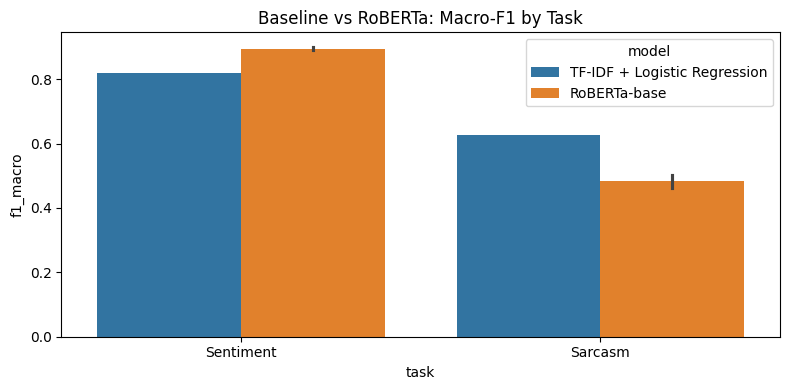

In [42]:
plt.figure(figsize=(8, 4))
sns.barplot(data=exp_21_results_df, x="task", y="f1_macro", hue="model")
plt.title("Baseline vs RoBERTa: Macro-F1 by Task")
plt.tight_layout()
plt.show()

### 2.2. Cross-variety Evaluation

In [43]:
def make_variety_subset(df, variety):
    return df[df["variety"] == variety].copy()

In [44]:
export HF_HOME=/scratch/$USER/hf_cache
export TRANSFORMERS_CACHE=/scratch/$USER/hf_cache
export TMPDIR=/scratch/$USER/tmpimport os
import gc
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

def run_cross_variety_experiment(label_col, source_variety, seed=42, num_train_epochs=2, batch_size=4):
    set_seed(seed)
    #xlmr
    model_name = "xlm-roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_src = make_variety_subset(train_df, source_variety)
    val_src = make_variety_subset(validation_df, source_variety)

    train_ds = make_hf_dataset_for_task(train_src, label_col, tokenizer)
    val_ds = make_hf_dataset_for_task(val_src, label_col, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        problem_type="single_label_classification"
    )

    output_dir = f"./tmp_crossvar_{label_col.lower()}_{source_variety}_seed{seed}"
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=False,
        report_to="none",
        seed=seed,
        fp16=torch.cuda.is_available(),
        bf16=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=hf_compute_metrics
    )

    trainer.train()

    results = []

#Evaluate on all target varieties
    for target_variety in ["en-UK", "en-AU", "en-IN"]:
        test_tgt = make_variety_subset(test_df, target_variety)
        test_ds = make_hf_dataset_for_task(test_tgt, label_col, tokenizer)

        test_output = trainer.predict(test_ds)
        test_preds = np.argmax(test_output.predictions, axis=-1)
        test_labels = test_output.label_ids

        test_metrics = compute_classification_metrics(test_labels, test_preds)

        results.append({
            "task": label_col,
            "train_variety": source_variety,
            "test_variety": target_variety,
            "seed": seed,
            **test_metrics
        })

    del trainer
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return pd.DataFrame(results)

In [45]:
#Running for Sentiment
all_cross_variety_results = []

for seed in [42, 7]:
    for source_variety in ["en-UK", "en-AU", "en-IN"]:
        df_res = run_cross_variety_experiment(
            label_col="Sentiment",     #"Sarcasm"
            source_variety=source_variety,
            seed=seed,
            num_train_epochs=2,
            batch_size=4
        )
        all_cross_variety_results.append(df_res)

cross_variety_results_df = pd.concat(all_cross_variety_results, ignore_index=True)
cross_variety_results_df.round(4)

Map:   0%|          | 0/1203 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Class 0,F1 Class 1
1,0.537387,0.596544,0.881188,0.886131,0.887352,0.881176,0.880000,0.882353
2,0.540878,0.464343,0.900990,0.900198,0.900198,0.900198,0.891304,0.909091


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Class 0,F1 Class 1
1,0.585470,0.491830,0.871795,0.870463,0.873084,0.871193,0.880000,0.862385
2,0.505379,0.680441,0.854701,0.856140,0.859080,0.854531,0.859504,0.849558


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/667 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

,task,train_variety,test_variety,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,Sentiment,en-UK,en-UK,42,0.8900,0.8901,0.8897,0.8899,0.8925,0.8877,0.8794,0.9000,0.8859,0.8938
1,Sentiment,en-UK,en-AU,42,0.7961,0.8088,0.7918,0.7921,0.7554,0.8622,0.8991,0.6844,0.8211,0.7631
2,Sentiment,en-UK,en-IN,42,0.7770,0.7771,0.7750,0.7756,0.7756,0.7787,0.8116,0.7383,0.7932,0.7580
3,Sentiment,en-AU,en-UK,42,0.9286,0.9294,0.9280,0.9284,0.9421,0.9167,0.9088,0.9472,0.9251,0.9317
4,Sentiment,en-AU,en-AU,42,0.8861,0.8891,0.8843,0.8853,0.8633,0.9150,0.9280,0.8406,0.8944,0.8762
5,Sentiment,en-AU,en-IN,42,0.8284,0.8281,0.8290,0.8282,0.8502,0.8060,0.8186,0.8394,0.8341,0.8223
6,Sentiment,en-IN,en-UK,42,0.8943,0.8963,0.8933,0.8939,0.9182,0.8743,0.8588,0.9278,0.8875,0.9003
7,Sentiment,en-IN,en-AU,42,0.8741,0.8743,0.8734,0.8737,0.8704,0.8782,0.8905,0.8562,0.8803,0.8671
8,Sentiment,en-IN,en-IN,42,0.8137,0.8136,0.8145,0.8136,0.8390,0.7882,0.8000,0.8290,0.8190,0.8081
9,Sentiment,en-UK,en-UK,7,0.9429,0.9433,0.9425,0.9428,0.9518,0.9348,0.9294,0.9556,0.9405,0.9451


In [46]:
cross_variety_summary = (
    cross_variety_results_df
    .groupby(["train_variety", "test_variety"], as_index=False)
    .agg({
        "accuracy": "mean",
        "precision_macro": "mean",
        "recall_macro": "mean",
        "f1_macro": "mean",
        "f1_class_0": "mean",
        "f1_class_1": "mean"
    })
)

cross_variety_summary.round(4)

,train_variety,test_variety,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,en-AU,en-AU,0.8801,0.8833,0.8782,0.8793,0.8891,0.8695
1,en-AU,en-IN,0.8241,0.8240,0.8249,0.8240,0.8292,0.8187
2,en-AU,en-UK,0.9207,0.9221,0.9200,0.9205,0.9163,0.9247
3,en-IN,en-AU,0.8651,0.8653,0.8644,0.8647,0.8718,0.8576
4,en-IN,en-IN,0.8223,0.8221,0.8230,0.8221,0.8276,0.8167
5,en-IN,en-UK,0.9000,0.9042,0.8987,0.8995,0.8922,0.9067
6,en-UK,en-AU,0.8276,0.8417,0.8234,0.8242,0.8485,0.7999
7,en-UK,en-IN,0.8076,0.8084,0.8055,0.8063,0.8221,0.7905
8,en-UK,en-UK,0.9164,0.9167,0.9161,0.9163,0.9132,0.9194


In [47]:
cross_variety_f1_matrix = cross_variety_summary.pivot(
    index="train_variety",
    columns="test_variety",
    values="f1_macro"
)

cross_variety_f1_matrix.round(4)

test_variety,en-AU,en-IN,en-UK
train_variety,,,
en-AU,0.8793,0.8240,0.9205
en-IN,0.8647,0.8221,0.8995
en-UK,0.8242,0.8063,0.9163


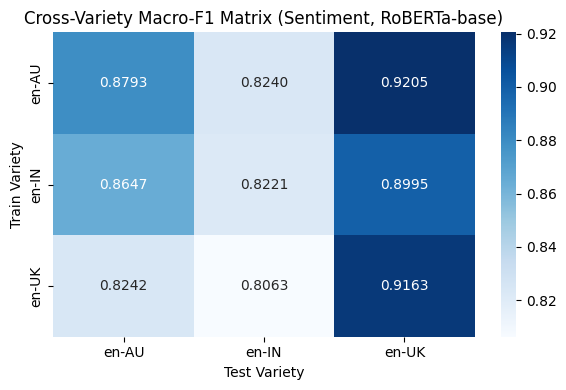

In [48]:
plt.figure(figsize=(6, 4))
sns.heatmap(cross_variety_f1_matrix, annot=True, fmt=".4f", cmap="Blues")
plt.title("Cross-Variety Macro-F1 Matrix (Sentiment, RoBERTa-base)")
plt.xlabel("Test Variety")
plt.ylabel("Train Variety")
plt.tight_layout()
plt.show()

In [49]:
#Computing transfer gap between varieties
transfer_gap_rows = []

for source_variety in ["en-UK", "en-AU", "en-IN"]:
    source_rows = cross_variety_summary[cross_variety_summary["train_variety"] == source_variety]

    in_variety_score = source_rows[source_rows["test_variety"] == source_variety]["f1_macro"].values[0]
    out_variety_score = source_rows[source_rows["test_variety"] != source_variety]["f1_macro"].mean()

    transfer_gap_rows.append({
        "train_variety": source_variety,
        "in_variety_f1": in_variety_score,
        "cross_variety_avg_f1": out_variety_score,
        "transfer_gap": in_variety_score - out_variety_score
    })

transfer_gap_df = pd.DataFrame(transfer_gap_rows)
transfer_gap_df.round(4)

,train_variety,in_variety_f1,cross_variety_avg_f1,transfer_gap
0,en-UK,0.9163,0.8153,0.1010
1,en-AU,0.8793,0.8722,0.0070
2,en-IN,0.8221,0.8821,-0.0599


### 2.3. LLM Variations fo Sarcasm detection

In [50]:
!pip install transformers peft trl bitsandbytes accelerate -q

In [51]:
import json
import time
from peft import LoraConfig, get_peft_model, PeftModel, prepare_model_for_kbit_training
from peft import get_peft_model
from trl import SFTTrainer, SFTConfig

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments, pipeline

from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer

In [52]:
print(get_peft_model)

<function get_peft_model at 0x7154e5ae2020>


In [53]:
BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
VARIETIES = ["en-UK", "en-AU", "en-IN"]
TASK_COL = "Sarcasm"
TEXT_COL = "text"
VARIETY_COL = "variety"

In [54]:
#Define functions
def sarcasm_label_to_text(x):
    return "sarcastic" if int(x) == 1 else "not_sarcastic"

In [55]:
def build_sft_example(text, label):
    return {
        "prompt": (
            "Classify the following text for sarcasm.\n"
            "Return only one label: sarcastic or not_sarcastic.\n\n"
            f"Text: {text}\n"
            "Label:"
        ),
        "completion": f" {sarcasm_label_to_text(label)}"
    }

In [56]:
def build_variety_sft_dataset(df, variety, max_rows=None):
    subset = df[df[VARIETY_COL] == variety].copy()

    if max_rows is not None:
        subset = subset.sample(n=min(max_rows, len(subset)), random_state=42)

    records = [
        build_sft_example(row[TEXT_COL], row[TASK_COL])
        for _, row in subset.iterrows()
    ]
    return Dataset.from_pandas(pd.DataFrame(records), preserve_index=False)

In [57]:
def merge_prompt_and_completion(example):
    example["text"] = example["prompt"] + example["completion"]
    return example

In [58]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

In [59]:
def load_base_llm():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.float16
    )

    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)

    return tokenizer, model

In [60]:
def build_lora_config():
    return LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
    )

In [61]:
def train_lora_adapter_for_variety(
    source_variety,
    output_dir,
    max_train_rows=None,
    max_val_rows=None,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4
#    seed=42
):
    tokenizer, base_model = load_base_llm()
    peft_config = build_lora_config()

    train_ds = build_variety_sft_dataset(train_df, source_variety, max_rows=max_train_rows)
    val_ds = build_variety_sft_dataset(validation_df, source_variety, max_rows=max_val_rows)

    os.makedirs(output_dir, exist_ok=True)

    sft_args = SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        fp16=False,
        bf16=False,
        max_length=256
    )

    set_seed(seed)

    trainer = SFTTrainer(
        model=base_model,
        args=sft_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        peft_config=peft_config,
        processing_class=tokenizer,   
    )

    trainer.train()

    #Save adapter
    trainer.model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    del trainer
    del base_model
    gc.collect()
    torch.cuda.empty_cache()

    return output_dir

In [62]:
import os
from peft import LoraConfig, get_peft_model
os.makedirs(f"{BASE_DIR}/artifacts", exist_ok=True)

adapter_dirs = {}

for variety in VARIETIES:
    adapter_dir = f"{BASE_DIR}/artifacts/lora_{variety.replace('-', '_')}"
    saved_dir = train_lora_adapter_for_variety(
        source_variety=variety,
        output_dir=adapter_dir,
        max_train_rows=800, 
        max_val_rows=150,
        num_train_epochs=1,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4
    )
    adapter_dirs[variety] = saved_dir

adapter_dirs

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/101 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/101 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/117 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/117 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.046328,0.053269


{'en-UK': '/scratch/vv00363/artifacts/lora_en_UK',
 'en-AU': '/scratch/vv00363/artifacts/lora_en_AU',
 'en-IN': '/scratch/vv00363/artifacts/lora_en_IN'}

In [63]:
def load_adapter_for_inference(adapter_dir):
    tokenizer, base_model = load_base_llm()
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    gen_pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=5,
        return_full_text=False
    )
    return gen_pipe

In [64]:
def parse_generated_label(text):
    text = text.strip().lower()

    if "not_sarcastic" in text:
        return 0
    if "sarcastic" in text:
        return 1

    return 0

In [65]:
def evaluate_adapter_on_variety(adapter_dir, target_variety, max_test_rows=None):
    gen_pipe = load_adapter_for_inference(adapter_dir)

    subset = test_df[test_df[VARIETY_COL] == target_variety].copy()
    if max_test_rows is not None:
        subset = subset.sample(n=min(max_test_rows, len(subset)), random_state=42)

    preds = []
    labels = subset[TASK_COL].astype(int).tolist()

    for text in subset[TEXT_COL].tolist():
        prompt = (
            "Classify the following text for sarcasm.\n"
            "Return only one label: sarcastic or not_sarcastic.\n\n"
            f"Text: {text}\n"
            "Label:"
        )
        output = gen_pipe(prompt)[0]["generated_text"]
        pred = parse_generated_label(output)
        preds.append(pred)

    metrics = compute_classification_metrics(labels, preds)

    del gen_pipe
    gc.collect()
    torch.cuda.empty_cache()

    return {
    "metrics": metrics,
    "labels": labels,   
    "preds": preds      
    }

In [66]:
#Run the experiment
adapter_results = []
confusion_store = {}

for train_variety, adapter_dir in adapter_dirs.items():
    for test_variety in VARIETIES:
        metrics = evaluate_adapter_on_variety(
            adapter_dir=adapter_dir,
            target_variety=test_variety,
            max_test_rows=300   #100??
        )

        adapter_results.append({
            "train_adapter": train_variety,
            "test_variety": test_variety,
            **metrics
        })

for train_variety, adapter_dir in adapter_dirs.items():
    for test_variety in VARIETIES:
        result = evaluate_adapter_on_variety(
            adapter_dir=adapter_dir,
            target_variety=test_variety,
            max_test_rows=300
        )
        
        adapter_results.append({
            "train_adapter": train_variety,
            "test_variety": test_variety,
            **result["metrics"]
        })

        key = f"{train_variety}->{test_variety}"
        confusion_store[key] = result

adapter_results_df = pd.DataFrame(adapter_results)
adapter_results_df.round(4)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=5) and `max_length`

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

,train_adapter,test_variety,metrics,labels,preds,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,en-UK,en-UK,"{'accuracy': 0.9166666666666666, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,en-UK,en-AU,"{'accuracy': 0.7033333333333334, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,en-UK,en-IN,"{'accuracy': 0.85, 'precision_macro': 0.504085...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,en-AU,en-UK,"{'accuracy': 0.7533333333333333, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,en-AU,en-AU,"{'accuracy': 0.7666666666666667, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,en-AU,en-IN,"{'accuracy': 0.7533333333333333, 'precision_ma...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,en-IN,en-UK,"{'accuracy': 0.9033333333333333, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,en-IN,en-AU,"{'accuracy': 0.7066666666666667, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,en-IN,en-IN,"{'accuracy': 0.9, 'precision_macro': 0.5307328...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,en-UK,en-UK,NaN,NaN,NaN,0.9000,0.6530,0.6413,0.6468,0.9424,0.3636,0.9493,0.3333,0.9458,0.3478


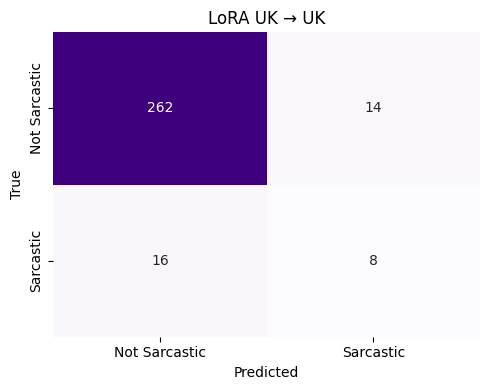

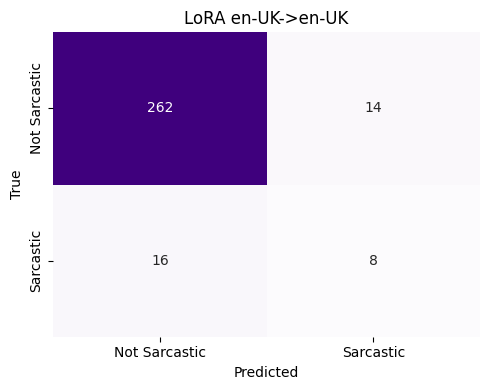

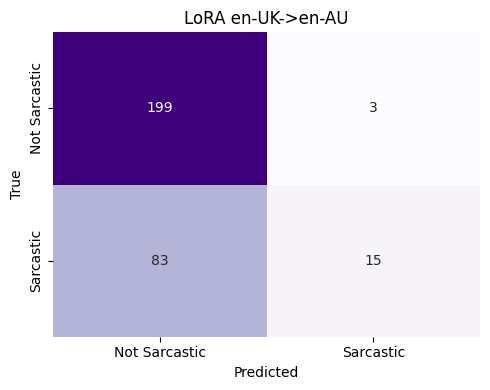

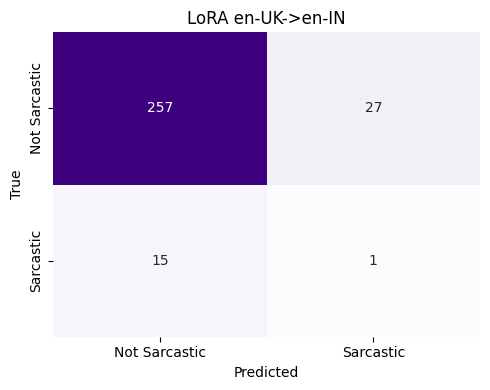

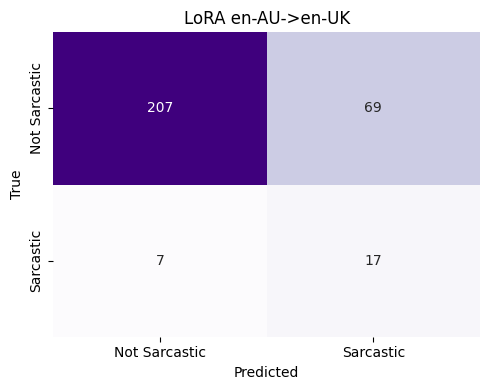

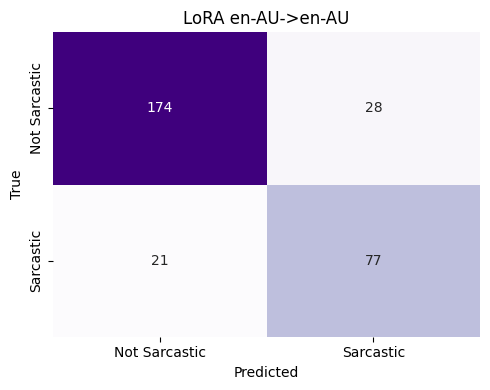

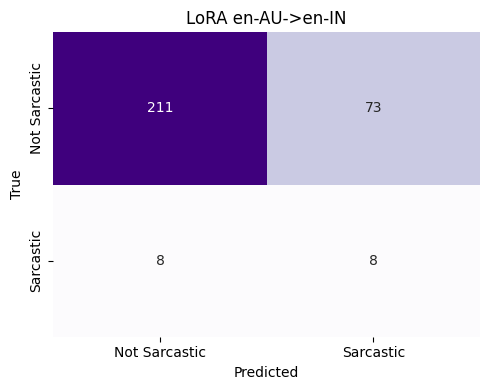

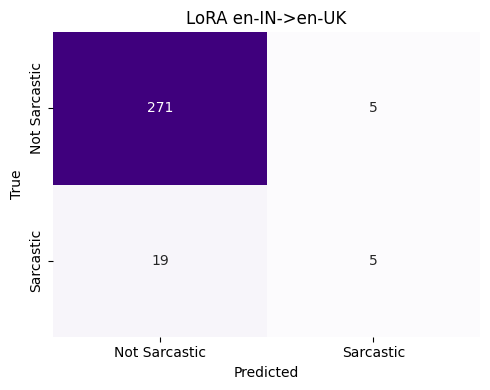

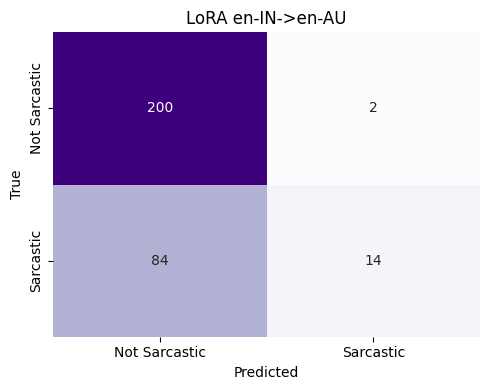

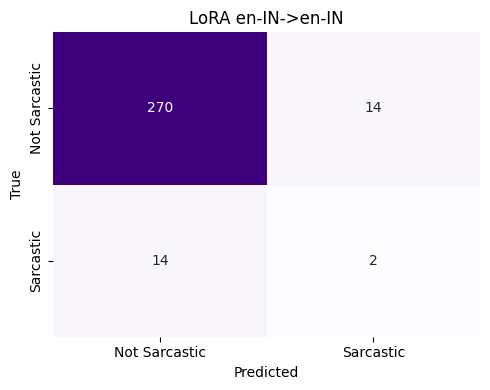

In [109]:
from sklearn.metrics import confusion_matrix
def plot_conf_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,annot=True,fmt='d',cmap='Purples',cbar=False,
        xticklabels=["Not Sarcastic", "Sarcastic"],
        yticklabels=["Not Sarcastic", "Sarcastic"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_conf_matrix(
    confusion_store["en-UK->en-UK"]["labels"],
    confusion_store["en-UK->en-UK"]["preds"],
    "LoRA UK → UK"
)

for key, data in confusion_store.items():
    plot_conf_matrix(
        data["labels"],
        data["preds"],
        f"LoRA {key}"
    )

In [110]:
#Results - Macro F1
adapter_f1_matrix = adapter_results_df.pivot_table(
    index="train_adapter",
    columns="test_variety",
    values="f1_macro"
)

adapter_f1_matrix.round(4)

test_variety,en-AU,en-IN,en-UK
train_adapter,,,
en-AU,0.8176,0.5020,0.5770
en-IN,0.5343,0.5379,0.6259
en-UK,0.5405,0.4850,0.6468


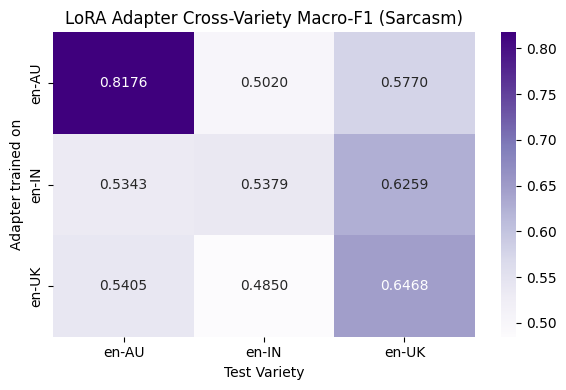

In [111]:
plt.figure(figsize=(6, 4))
sns.heatmap(adapter_f1_matrix, annot=True, fmt=".4f", cmap="Purples")
plt.title("LoRA Adapter Cross-Variety Macro-F1 (Sarcasm)")
plt.xlabel("Test Variety")
plt.ylabel("Adapter trained on")
plt.tight_layout()
plt.show()

### 3. Evaluation

Experiment 2.1

In [72]:
#Experiment 2.1 summary
print("Experiment 2.1 Summary")
display(exp_21_summary.round(4))

Experiment 2.1 Summary


,task,model,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,Sarcasm,RoBERTa-base,0.8598,0.5479,0.5093,0.4831,0.9244,0.0418
1,Sarcasm,TF-IDF + Logistic Regression,0.7572,0.6141,0.6859,0.6254,0.8476,0.4032
2,Sentiment,RoBERTa-base,0.8949,0.8951,0.8949,0.8948,0.8969,0.8927
3,Sentiment,TF-IDF + Logistic Regression,0.8186,0.8190,0.8181,0.8183,0.8256,0.8111


In [73]:
print("Experiment 2.1 Individual Runs")
display(exp_21_results_df.round(4))

Experiment 2.1 Individual Runs


,task,model,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,Sentiment,TF-IDF + Logistic Regression,42,0.8186,0.8190,0.8181,0.8183,0.8127,0.8252,0.8389,0.7974,0.8256,0.8111
1,Sentiment,RoBERTa-base,42,0.8891,0.8893,0.8895,0.8891,0.9047,0.8739,0.8756,0.9034,0.8899,0.8884
2,Sentiment,TF-IDF + Logistic Regression,7,0.8186,0.8190,0.8181,0.8183,0.8127,0.8252,0.8389,0.7974,0.8256,0.8111
3,Sentiment,RoBERTa-base,7,0.9006,0.9009,0.9003,0.9005,0.8947,0.9070,0.9132,0.8874,0.9039,0.8971
4,Sarcasm,TF-IDF + Logistic Regression,42,0.7572,0.6141,0.6859,0.6254,0.9212,0.3070,0.7849,0.5869,0.8476,0.4032
5,Sarcasm,RoBERTa-base,42,0.8603,0.4301,0.5000,0.4624,0.8603,0.0000,1.0000,0.0000,0.9249,0.0000
6,Sarcasm,TF-IDF + Logistic Regression,7,0.7572,0.6141,0.6859,0.6254,0.9212,0.3070,0.7849,0.5869,0.8476,0.4032
7,Sarcasm,RoBERTa-base,7,0.8594,0.6658,0.5187,0.5037,0.8648,0.4667,0.9915,0.0459,0.9238,0.0836


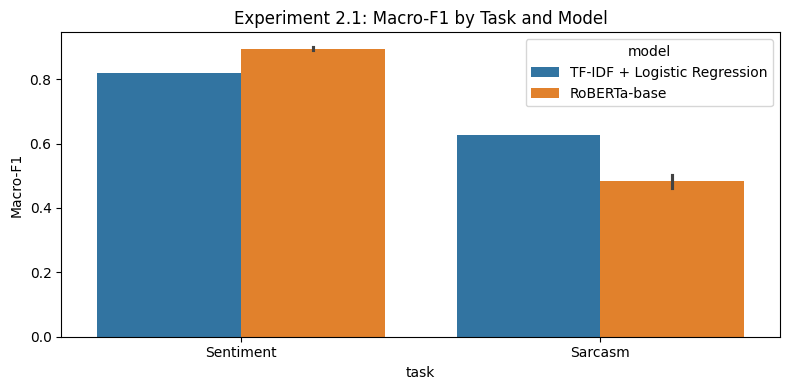

In [74]:
#Comparing Macro-f1
plt.figure(figsize=(8, 4))
sns.barplot(data=exp_21_results_df, x="task", y="f1_macro", hue="model")
plt.title("Experiment 2.1: Macro-F1 by Task and Model")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.show()

,task,model,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,Sarcasm,RoBERTa-base,0.8598,0.5479,0.5093,0.4831,0.9244,0.0418
1,Sarcasm,TF-IDF + Logistic Regression,0.7572,0.6141,0.6859,0.6254,0.8476,0.4032
2,Sentiment,RoBERTa-base,0.8949,0.8951,0.8949,0.8948,0.8969,0.8927
3,Sentiment,TF-IDF + Logistic Regression,0.8186,0.8190,0.8181,0.8183,0.8256,0.8111


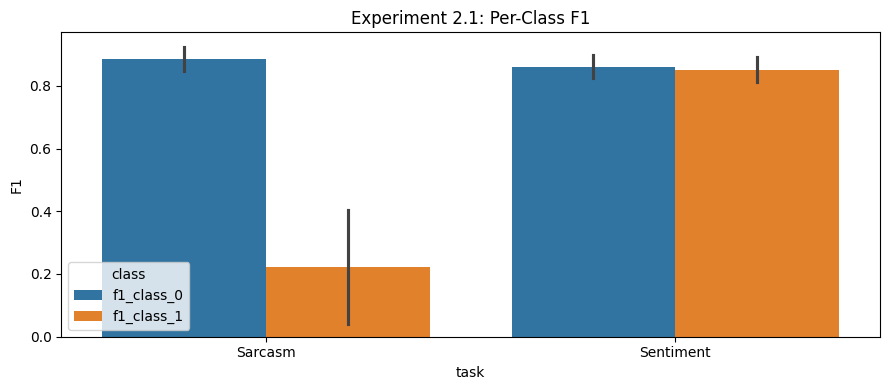

In [75]:
#Per-class f1
exp_21_per_class = exp_21_summary[[
    "task", "model", "accuracy", "precision_macro", "recall_macro",
    "f1_macro", "f1_class_0", "f1_class_1"
]].copy()

display(exp_21_per_class.round(4))

exp_21_plot_df = exp_21_summary.melt(
    id_vars=["task", "model"],
    value_vars=["f1_class_0", "f1_class_1"],
    var_name="class",
    value_name="f1"
)

plt.figure(figsize=(9, 4))
sns.barplot(data=exp_21_plot_df, x="task", y="f1", hue="class")
plt.title("Experiment 2.1: Per-Class F1")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

In [76]:
#Best 2.1 run 
best_21 = exp_21_results_df.sort_values("f1_macro", ascending=False).iloc[0]
print("Best Experiment 2.1 Run:")
display(pd.DataFrame([best_21]).round(4))

Best Experiment 2.1 Run:


,task,model,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
3,Sentiment,RoBERTa-base,7,0.9006,0.9009,0.9003,0.9005,0.8947,0.907,0.9132,0.8874,0.9039,0.8971


Experiment 2.2

In [77]:
#Experiment 2.2 summary (executed for Sentiment)
print("Experiment 2.2 Individual Runs")
display(cross_variety_results_df.round(4))

Experiment 2.2 Individual Runs


,task,train_variety,test_variety,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,Sentiment,en-UK,en-UK,42,0.8900,0.8901,0.8897,0.8899,0.8925,0.8877,0.8794,0.9000,0.8859,0.8938
1,Sentiment,en-UK,en-AU,42,0.7961,0.8088,0.7918,0.7921,0.7554,0.8622,0.8991,0.6844,0.8211,0.7631
2,Sentiment,en-UK,en-IN,42,0.7770,0.7771,0.7750,0.7756,0.7756,0.7787,0.8116,0.7383,0.7932,0.7580
3,Sentiment,en-AU,en-UK,42,0.9286,0.9294,0.9280,0.9284,0.9421,0.9167,0.9088,0.9472,0.9251,0.9317
4,Sentiment,en-AU,en-AU,42,0.8861,0.8891,0.8843,0.8853,0.8633,0.9150,0.9280,0.8406,0.8944,0.8762
5,Sentiment,en-AU,en-IN,42,0.8284,0.8281,0.8290,0.8282,0.8502,0.8060,0.8186,0.8394,0.8341,0.8223
6,Sentiment,en-IN,en-UK,42,0.8943,0.8963,0.8933,0.8939,0.9182,0.8743,0.8588,0.9278,0.8875,0.9003
7,Sentiment,en-IN,en-AU,42,0.8741,0.8743,0.8734,0.8737,0.8704,0.8782,0.8905,0.8562,0.8803,0.8671
8,Sentiment,en-IN,en-IN,42,0.8137,0.8136,0.8145,0.8136,0.8390,0.7882,0.8000,0.8290,0.8190,0.8081
9,Sentiment,en-UK,en-UK,7,0.9429,0.9433,0.9425,0.9428,0.9518,0.9348,0.9294,0.9556,0.9405,0.9451


In [78]:
#Macro f1 results
cross_variety_f1_matrix = cross_variety_summary.pivot(
    index="train_variety",
    columns="test_variety",
    values="f1_macro"
)

display(cross_variety_f1_matrix.round(4))

test_variety,en-AU,en-IN,en-UK
train_variety,,,
en-AU,0.8793,0.8240,0.9205
en-IN,0.8647,0.8221,0.8995
en-UK,0.8242,0.8063,0.9163


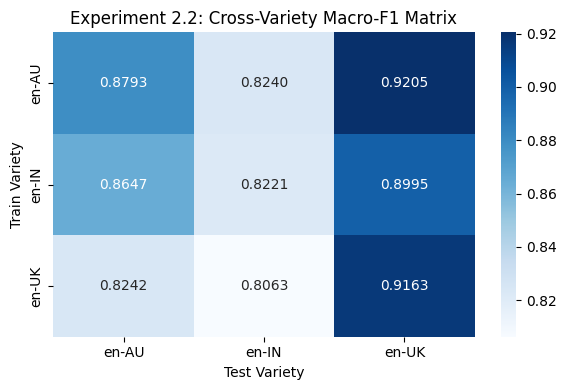

In [79]:
plt.figure(figsize=(6, 4))
sns.heatmap(cross_variety_f1_matrix, annot=True, fmt=".4f", cmap="Blues")
plt.title("Experiment 2.2: Cross-Variety Macro-F1 Matrix")
plt.xlabel("Test Variety")
plt.ylabel("Train Variety")
plt.tight_layout()
plt.show()

In [80]:
#Per-class results
display(
    cross_variety_summary[[
        "train_variety", "test_variety",
        "accuracy", "precision_macro", "recall_macro",
        "f1_macro", "f1_class_0", "f1_class_1"
    ]].round(4)
)

,train_variety,test_variety,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,en-AU,en-AU,0.8801,0.8833,0.8782,0.8793,0.8891,0.8695
1,en-AU,en-IN,0.8241,0.8240,0.8249,0.8240,0.8292,0.8187
2,en-AU,en-UK,0.9207,0.9221,0.9200,0.9205,0.9163,0.9247
3,en-IN,en-AU,0.8651,0.8653,0.8644,0.8647,0.8718,0.8576
4,en-IN,en-IN,0.8223,0.8221,0.8230,0.8221,0.8276,0.8167
5,en-IN,en-UK,0.9000,0.9042,0.8987,0.8995,0.8922,0.9067
6,en-UK,en-AU,0.8276,0.8417,0.8234,0.8242,0.8485,0.7999
7,en-UK,en-IN,0.8076,0.8084,0.8055,0.8063,0.8221,0.7905
8,en-UK,en-UK,0.9164,0.9167,0.9161,0.9163,0.9132,0.9194


In [81]:
#Transfer gap
transfer_gap_rows = []

for source_variety in ["en-UK", "en-AU", "en-IN"]:
    source_rows = cross_variety_summary[cross_variety_summary["train_variety"] == source_variety]

    in_variety_score = source_rows[source_rows["test_variety"] == source_variety]["f1_macro"].values[0]
    out_variety_score = source_rows[source_rows["test_variety"] != source_variety]["f1_macro"].mean()

    transfer_gap_rows.append({
        "train_variety": source_variety,
        "in_variety_f1": in_variety_score,
        "cross_variety_avg_f1": out_variety_score,
        "transfer_gap": in_variety_score - out_variety_score
    })

transfer_gap_df = pd.DataFrame(transfer_gap_rows)
display(transfer_gap_df.round(4))

,train_variety,in_variety_f1,cross_variety_avg_f1,transfer_gap
0,en-UK,0.9163,0.8153,0.1010
1,en-AU,0.8793,0.8722,0.0070
2,en-IN,0.8221,0.8821,-0.0599


In [82]:
#Best run results for 2.2 
best_22 = cross_variety_results_df.sort_values("f1_macro", ascending=False).iloc[0]
print("Best Experiment 2.2 Run:")
display(pd.DataFrame([best_22]).round(4))

Best Experiment 2.2 Run:


,task,train_variety,test_variety,seed,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
9,Sentiment,en-UK,en-UK,7,0.9429,0.9433,0.9425,0.9428,0.9518,0.9348,0.9294,0.9556,0.9405,0.9451


Experiment 2.3

In [83]:
#Experiment 2.3 Summary
print("Experiment 2.3 Summary")
display(adapter_results_df.round(4))

Experiment 2.3 Summary


,train_adapter,test_variety,metrics,labels,preds,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
0,en-UK,en-UK,"{'accuracy': 0.9166666666666666, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,en-UK,en-AU,"{'accuracy': 0.7033333333333334, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,en-UK,en-IN,"{'accuracy': 0.85, 'precision_macro': 0.504085...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,en-AU,en-UK,"{'accuracy': 0.7533333333333333, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,en-AU,en-AU,"{'accuracy': 0.7666666666666667, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,en-AU,en-IN,"{'accuracy': 0.7533333333333333, 'precision_ma...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,en-IN,en-UK,"{'accuracy': 0.9033333333333333, 'precision_ma...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,en-IN,en-AU,"{'accuracy': 0.7066666666666667, 'precision_ma...","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,en-IN,en-IN,"{'accuracy': 0.9, 'precision_macro': 0.5307328...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,en-UK,en-UK,NaN,NaN,NaN,0.9000,0.6530,0.6413,0.6468,0.9424,0.3636,0.9493,0.3333,0.9458,0.3478


In [85]:
#Macro f1 results
adapter_f1_matrix = adapter_results_df.pivot_table(
    index="train_adapter",
    columns="test_variety",
    values="f1_macro"
)

display(adapter_f1_matrix.round(4))

test_variety,en-AU,en-IN,en-UK
train_adapter,,,
en-AU,0.8176,0.5020,0.5770
en-IN,0.5343,0.5379,0.6259
en-UK,0.5405,0.4850,0.6468


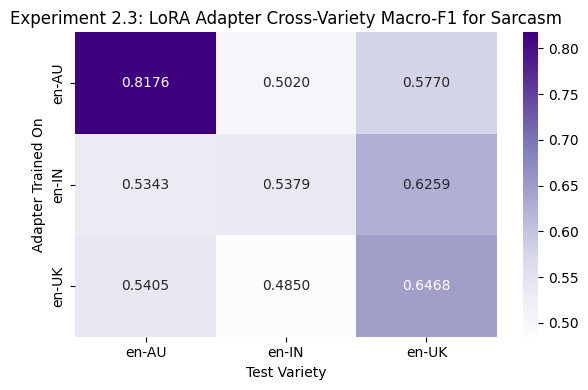

In [86]:
plt.figure(figsize=(6, 4))
sns.heatmap(adapter_f1_matrix, annot=True, fmt=".4f", cmap="Purples")
plt.title("Experiment 2.3: LoRA Adapter Cross-Variety Macro-F1 for Sarcasm")
plt.xlabel("Test Variety")
plt.ylabel("Adapter Trained On")
plt.tight_layout()
plt.show()

In [87]:
#Per-class results
display(
    adapter_results_df[[
        "train_adapter", "test_variety",
        "accuracy", "precision_macro", "recall_macro",
        "f1_macro", "f1_class_0", "f1_class_1"
    ]].round(4)
)

,train_adapter,test_variety,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,en-UK,en-UK,NaN,NaN,NaN,NaN,NaN,NaN
1,en-UK,en-AU,NaN,NaN,NaN,NaN,NaN,NaN
2,en-UK,en-IN,NaN,NaN,NaN,NaN,NaN,NaN
3,en-AU,en-UK,NaN,NaN,NaN,NaN,NaN,NaN
4,en-AU,en-AU,NaN,NaN,NaN,NaN,NaN,NaN
5,en-AU,en-IN,NaN,NaN,NaN,NaN,NaN,NaN
6,en-IN,en-UK,NaN,NaN,NaN,NaN,NaN,NaN
7,en-IN,en-AU,NaN,NaN,NaN,NaN,NaN,NaN
8,en-IN,en-IN,NaN,NaN,NaN,NaN,NaN,NaN
9,en-UK,en-UK,0.9000,0.6530,0.6413,0.6468,0.9458,0.3478


In [88]:
#Average performance per adapter
adapter_summary = (
    adapter_results_df
    .groupby("train_adapter", as_index=False)
    .agg({
        "accuracy": "mean",
        "precision_macro": "mean",
        "recall_macro": "mean",
        "f1_macro": "mean",
        "f1_class_0": "mean",
        "f1_class_1": "mean"
    })
)

display(adapter_summary.round(4))

,train_adapter,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,en-AU,0.7711,0.6421,0.7247,0.6322,0.8535,0.4109
1,en-IN,0.8467,0.6816,0.5665,0.5660,0.9104,0.2216
2,en-UK,0.8244,0.6376,0.5647,0.5574,0.8975,0.2173


In [89]:
#Best run in 2.3
best_23 = adapter_results_df.sort_values("f1_macro", ascending=False).iloc[0]
print("Best Experiment 2.3 Run:")
display(pd.DataFrame([best_23]).round(4))

Best Experiment 2.3 Run:


,train_adapter,test_variety,metrics,labels,preds,accuracy,precision_macro,recall_macro,f1_macro,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1
13,en-AU,en-AU,NaN,NaN,NaN,0.8367,0.8128,0.8236,0.8176,0.8923,0.7333,0.8614,0.7857,0.8766,0.7586


In [90]:
#Overall results
overall_best_df = pd.DataFrame([
    {
        "experiment": "2.1 Baseline/PTLM Gap",
        "setting": f"{best_21['task']} | {best_21['model']} | seed={best_21['seed']}",
        "accuracy": best_21["accuracy"],
        "precision_macro": best_21["precision_macro"],
        "recall_macro": best_21["recall_macro"],
        "f1_macro": best_21["f1_macro"],
        "f1_class_0": best_21["f1_class_0"],
        "f1_class_1": best_21["f1_class_1"],
    },
    {
        "experiment": "2.2 Cross-variety",
        "setting": f"{best_22['train_variety']} to {best_22['test_variety']} | seed={best_22['seed']}",
        "accuracy": best_22["accuracy"],
        "precision_macro": best_22["precision_macro"],
        "recall_macro": best_22["recall_macro"],
        "f1_macro": best_22["f1_macro"],
        "f1_class_0": best_22["f1_class_0"],
        "f1_class_1": best_22["f1_class_1"],
    },
    {
        "experiment": "2.3 LoRA Variations",
        "setting": f"{best_23['train_adapter']} to {best_23['test_variety']}",
        "accuracy": best_23["accuracy"],
        "precision_macro": best_23["precision_macro"],
        "recall_macro": best_23["recall_macro"],
        "f1_macro": best_23["f1_macro"],
        "f1_class_0": best_23["f1_class_0"],
        "f1_class_1": best_23["f1_class_1"],
    }
])

display(overall_best_df.round(4))

,experiment,setting,accuracy,precision_macro,recall_macro,f1_macro,f1_class_0,f1_class_1
0,2.1 Baseline/PTLM Gap,Sentiment | RoBERTa-base | seed=7,0.9006,0.9009,0.9003,0.9005,0.9039,0.8971
1,2.2 Cross-variety,en-UK to en-UK | seed=7,0.9429,0.9433,0.9425,0.9428,0.9405,0.9451
2,2.3 LoRA Variations,en-AU to en-AU,0.8367,0.8128,0.8236,0.8176,0.8766,0.7586


In [91]:
# plt.figure(figsize=(7, 4))
# sns.barplot(data=overall_best_df, x="experiment", y="f1_macro")
# plt.title("Best Macro-F1 from Each Experiment")
# plt.ylabel("Macro-F1")
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

## 4. Sarcasm Explanation & Error Analysis

In [92]:
best_23 = adapter_results_df.sort_values("f1_macro", ascending=False).iloc[0]
best_23

train_adapter           en-AU
test_variety            en-AU
metrics                   NaN
labels                    NaN
preds                     NaN
accuracy             0.836667
precision_macro      0.812821
recall_macro          0.82355
f1_macro             0.817597
precision_class_0    0.892308
precision_class_1    0.733333
recall_class_0       0.861386
recall_class_1       0.785714
f1_class_0           0.876574
f1_class_1           0.758621
Name: 13, dtype: object

In [93]:
#best adapter-target pair from previous results
best_23 = adapter_results_df.sort_values("f1_macro", ascending=False).iloc[0]

def get_misclassified_examples_from_best_23(best_23, adapter_dirs, max_test_rows=None):
    train_adapter = best_23["train_adapter"]
    test_variety = best_23["test_variety"]

    adapter_dir = adapter_dirs[train_adapter]
    gen_pipe = load_adapter_for_inference(adapter_dir)

    subset = test_df[test_df["variety"] == test_variety].copy()

    if max_test_rows is not None:
        subset = subset.sample(n=min(max_test_rows, len(subset)), random_state=42).copy()

    preds = []

    for text in subset["text"].tolist():
        prompt = (
            "Classify the following text for sarcasm.\n"
            "Return only one label: sarcastic or non sarcastic.\n\n"
            f"Text: {text}\n"
            "Label:"
        )
        output = gen_pipe(prompt)[0]["generated_text"]
        pred = parse_generated_label(output)
        preds.append(pred)

    subset = subset.copy()
    subset["predicted_label"] = preds
    subset["true_label"] = subset["Sarcasm"].astype(int)
    subset["correct"] = subset["predicted_label"] == subset["true_label"]

    label_map = {0: "not_sarcastic", 1: "sarcastic"}
    subset["true_label_text"] = subset["true_label"].map(label_map)
    subset["predicted_label_text"] = subset["predicted_label"].map(label_map)

    misclassified = subset[subset["correct"] == False].copy()

    print("Best adapter trained on:", train_adapter)
    print("Evaluated on test variety:", test_variety)
    print("Total examples checked:", len(subset))
    print("Misclassified examples found:", len(misclassified))

    del gen_pipe
    gc.collect()
    torch.cuda.empty_cache()

    return misclassified, subset

In [94]:
misclassified_df, checked_df = get_misclassified_examples_from_best_23(
    best_23=best_23,
    adapter_dirs=adapter_dirs,
    max_test_rows=100
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Best adapter trained on: en-AU
Evaluated on test variety: en-AU
Total examples checked: 100
Misclassified examples found: 64


In [95]:
# from sklearn.metrics import confusion_matrix, classification_report
# y_true = checked_df["true_label"]
# y_pred = checked_df["predicted_label"]

# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(5, 4))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=["not_sarcastic", "sarcastic"],
#     yticklabels=["not_sarcastic", "sarcastic"]
# )
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.title(f"Confusion Matrix: Best 2.3 Adapter ({best_23['train_adapter']} → {best_23['test_variety']})")
# plt.tight_layout()
# plt.show()

# print(classification_report(
#     y_true,
#     y_pred,
#     target_names=["not_sarcastic", "sarcastic"],
#     digits=4,
#     zero_division=0
# ))

In [96]:
misclassified_df[[
    "text", "variety", "source",
    "true_label_text", "predicted_label_text"
]].head(10)

,text,variety,source,true_label_text,predicted_label_text
2156,The enclosed park is good except it has a buil...,en-AU,Google,not_sarcastic,sarcastic
488,"smart move for Albo to stay out of it, trumps ...",en-AU,Reddit,not_sarcastic,sarcastic
2049,Man Richmond station needs a Reno looking at t...,en-AU,Reddit,not_sarcastic,sarcastic
1144,Had a closed sign in door even though they wer...,en-AU,Google,not_sarcastic,sarcastic
1348,Classics: The Everleigh\nModern: Caretakers Co...,en-AU,Reddit,not_sarcastic,sarcastic
1781,Very tasteful dumplings. Juicy bun was not Jui...,en-AU,Google,not_sarcastic,sarcastic
267,You're comparing possession charges to distrib...,en-AU,Reddit,not_sarcastic,sarcastic
897,We can through Bendigo on a sunny Sunday after...,en-AU,Google,not_sarcastic,sarcastic
1121,Fantastic meal with a choice of two sides and ...,en-AU,Google,not_sarcastic,sarcastic
666,I have been here a few times before. This time...,en-AU,Google,not_sarcastic,sarcastic


In [97]:
misclassified_df.to_csv("misclassified_best_23_adapter.csv", index=False)

In [98]:
#Sarcastic predicted as not_sarcastic
sarcasm_as_nonsarcasm = misclassified_df[(misclassified_df["true_label"] == 1) & (misclassified_df["predicted_label"] == 0)].head(5).copy()

#Nonsarcastic predicted as sarcastic
nonsarcasm_as_sarcasm = misclassified_df[(misclassified_df["true_label"] == 0) &(misclassified_df["predicted_label"] == 1)].head(5).copy()

In [99]:
sarcasm_as_nonsarcasm.head(5)

,text,variety,source,Sentiment,Sarcasm,predicted_label,true_label,correct,true_label_text,predicted_label_text


In [100]:
nonsarcasm_as_sarcasm.head(5)

,text,variety,source,Sentiment,Sarcasm,predicted_label,true_label,correct,true_label_text,predicted_label_text
2156,The enclosed park is good except it has a buil...,en-AU,Google,1,0,1,0,False,not_sarcastic,sarcastic
488,"smart move for Albo to stay out of it, trumps ...",en-AU,Reddit,1,0,1,0,False,not_sarcastic,sarcastic
2049,Man Richmond station needs a Reno looking at t...,en-AU,Reddit,0,0,1,0,False,not_sarcastic,sarcastic
1144,Had a closed sign in door even though they wer...,en-AU,Google,0,0,1,0,False,not_sarcastic,sarcastic
1348,Classics: The Everleigh\nModern: Caretakers Co...,en-AU,Reddit,1,0,1,0,False,not_sarcastic,sarcastic


In [101]:
#Save in csv files for manual error analysis
sarcasm_as_nonsarcasm.to_csv("sarcasm_as_nonsarcasm.csv", index=False)

In [102]:
nonsarcasm_as_sarcasm.to_csv("nonsarcasm_as_sarcasm.csv", index=False)

Code used in relation to Deployment

In [103]:
# #Hosting on huggingface
# from huggingface_hub import create_repo
# create_repo("Ahila-J/pg10-sentiment", repo_type="model", exist_ok=True)
# create_repo("Ahila-J/pg10-sarcasm-lora-en-uk", repo_type="model", exist_ok=True)
# create_repo("Ahila-J/pg10-sarcasm-lora-en-au", repo_type="model", exist_ok=True)
# create_repo("Ahila-J/pg10-sarcasm-lora-en-in", repo_type="model", exist_ok=True)

# print("Repos created.")

In [104]:
# from huggingface_hub import HfApi

# api = HfApi()

# #Sentiment
# api.upload_file(
#     path_or_fileobj="./artifacts/sklearn_sentiment_pooled.pkl",
#     path_in_repo="sklearn_sentiment_pooled.pkl",
#     repo_id="Ahila-J/pg10-sentiment",
#     repo_type="model",
# )

# #lora_en_UK
# api.upload_folder(
#     folder_path="./artifacts/lora_en_UK",
#     repo_id="Ahila-J/pg10-sarcasm-lora-en-uk",
#     repo_type="model",
# )

# #lora_en_AU
# api.upload_folder(
#     folder_path="./artifacts/lora_en_AU",
#     repo_id="Ahila-J/pg10-sarcasm-lora-en-au",
#     repo_type="model",
# )

# #lora-en-in
# api.upload_folder(
#     folder_path="./artifacts/lora_en_IN",
#     repo_id="Ahila-J/pg10-sarcasm-lora-en-in",
#     repo_type="model",
# )

# print("Upload complete.")

In [105]:
# from huggingface_hub import hf_hub_download

# path = hf_hub_download(
#     repo_id="Ahila-J/pg10-sentiment",
#     filename="sklearn_sentiment_pooled.pkl",
# )
# print(path)

In [106]:
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from peft import PeftModel

# BASE_LLM = "Qwen/Qwen2.5-1.5B-Instruct"
# adapter_repo = "Ahila-J/pg10-sarcasm-lora-en-au"

# tokenizer = AutoTokenizer.from_pretrained(BASE_LLM, use_fast=True)
# base_model = AutoModelForCausalLM.from_pretrained(BASE_LLM)
# model = PeftModel.from_pretrained(base_model, adapter_repo)

# print("Adapter loaded successfully.")